<a href="https://colab.research.google.com/github/tanusreemajumder/Neural-Networks-Andrew-Ng/blob/main/part_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

np.random.seed(1)
print("NumPy version:", np.__version__)

NumPy version: 2.1.3


In [13]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
df = pd.read_csv('/content/drive/MyDrive/Housing.csv')


In [15]:
median_price = df["price"].median()
df["expensive"] = (df["price"] > median_price).astype(int)

yes_no_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for col in yes_no_cols:
    df[col] = (df[col] == "yes").astype(int)

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True, dtype=int)

feature_cols = [c for c in df.columns if c not in ("price", "expensive")]
X_raw = df[feature_cols].values.astype(float)
Y_raw = df["expensive"].values.reshape(-1, 1).astype(float)

n_x = X_raw.shape[1]
print("n_x (features):", n_x, " total examples:", X_raw.shape[0])

n_x (features): 13  total examples: 545


In [16]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid_derivative(a):
    return a * (1 - a)

def initialize_parameters_deep(layer_dims, seed=1):
    rng = np.random.RandomState(seed)
    parameters = {}
    L = len(layer_dims) - 1
    for l in range(1, L + 1):
        # He initialization: scales with sqrt(2/n_prev), works well with ReLU
        parameters[f"W{l}"] = rng.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2.0 / layer_dims[l-1])
        parameters[f"b{l}"] = np.zeros((layer_dims[l], 1))
    return parameters

def compute_cost(AL, Y, eps=1e-8):
    m = Y.shape[1]
    ALc = np.clip(AL, eps, 1 - eps)
    return np.squeeze(-(1.0 / m) * np.sum(Y * np.log(ALc) + (1 - Y) * np.log(1 - ALc)))

def L_model_forward(X, parameters):
    caches = []
    A = X
    L = len(parameters) // 2
    for l in range(1, L):
        A_prev = A
        Z = np.dot(parameters[f"W{l}"], A_prev) + parameters[f"b{l}"]
        A = relu(Z)
        caches.append((A_prev, parameters[f"W{l}"], parameters[f"b{l}"], Z))
    ZL = np.dot(parameters[f"W{L}"], A) + parameters[f"b{L}"]
    AL = sigmoid(ZL)
    caches.append((A, parameters[f"W{L}"], parameters[f"b{L}"], ZL))
    return AL, caches

def L_model_backward(AL, Y, caches):
    grads = {}
    L = len(caches)
    Y = Y.reshape(AL.shape)
    dAL = -(np.divide(Y, np.clip(AL, 1e-8, 1)) - np.divide(1 - Y, np.clip(1 - AL, 1e-8, 1)))

    A_prev, W, b, Z = caches[L - 1]
    m = A_prev.shape[1]
    dZ = dAL * sigmoid_derivative(AL)
    grads[f"dW{L}"] = (1.0/m) * np.dot(dZ, A_prev.T)
    grads[f"db{L}"] = (1.0/m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)

    for l in reversed(range(1, L)):
        A_prev, W, b, Z = caches[l - 1]
        m = A_prev.shape[1]
        dZ = dA_prev * relu_derivative(Z)
        grads[f"dW{l}"] = (1.0/m) * np.dot(dZ, A_prev.T)
        grads[f"db{l}"] = (1.0/m) * np.sum(dZ, axis=1, keepdims=True)
        dA_prev = np.dot(W.T, dZ)

    return grads

def update_parameters_deep(parameters, grads, alpha):
    L = len(parameters) // 2
    for l in range(1, L + 1):
        parameters[f"W{l}"] -= alpha * grads[f"dW{l}"]
        parameters[f"b{l}"] -= alpha * grads[f"db{l}"]
    return parameters

def predict_deep(parameters, X, threshold=0.5):
    AL, _ = L_model_forward(X, parameters)
    return (AL > threshold).astype(int)

print("Building blocks (re)defined and ready.")

Building blocks (re)defined and ready.


## 1. Why Deep Representation

Two intuitions for why depth helps, beyond just "more parameters":

**Hierarchical features.** Early layers can learn simple patterns; later layers combine those into increasingly complex ones (e.g. edges -> parts -> objects in image recognition). Each layer reuses and recombines what earlier layers already learned, rather than learning everything from scratch in one giant layer.

**Circuit complexity.** Some functions that are compositional (built from simpler sub-functions) can be computed by a deep network with relatively few units *per layer*, but would require an **exponentially larger** shallow (1-hidden-layer) network to approximate.

The classic example is **parity** (XOR of many bits): is the number of 1s in the input even or odd? Below, we test this directly — train shallow vs. deep networks of *comparable total parameter count* on a parity-like task, and see which one actually manages to learn it.

In [17]:
def make_parity_dataset(n_bits=8, m=2000, seed=10):
    rng = np.random.RandomState(seed)
    X = rng.randint(0, 2, size=(n_bits, m)).astype(float)
    Y = (np.sum(X, axis=0) % 2).reshape(1, m).astype(float)  # 1 if odd number of 1s
    return X, Y

n_bits = 8
X_parity, Y_parity = make_parity_dataset(n_bits=n_bits, m=2000)
split = 1600
X_parity_train, X_parity_dev = X_parity[:, :split], X_parity[:, split:]
Y_parity_train, Y_parity_dev = Y_parity[:, :split], Y_parity[:, split:]

print("Parity dataset:", X_parity_train.shape, "-> label = 1 if the number of 1-bits is odd")
print("This is NOT linearly separable and is a classic hard case for shallow networks.")

Parity dataset: (8, 1600) -> label = 1 if the number of 1-bits is odd
This is NOT linearly separable and is a classic hard case for shallow networks.


In [18]:
def count_parameters(layer_dims):
    total = 0
    for l in range(1, len(layer_dims)):
        total += layer_dims[l] * layer_dims[l-1] + layer_dims[l]
    return total

def train_and_eval(layer_dims, X_train, Y_train, X_dev, Y_dev, num_iterations=3000, alpha=0.3, seed=1):
    params = initialize_parameters_deep(layer_dims, seed=seed)
    for it in range(num_iterations):
        AL, caches = L_model_forward(X_train, params)
        grads = L_model_backward(AL, Y_train, caches)
        params = update_parameters_deep(params, grads, alpha)
    train_acc = np.mean(predict_deep(params, X_train) == Y_train) * 100
    dev_acc   = np.mean(predict_deep(params, X_dev)   == Y_dev)   * 100
    return train_acc, dev_acc, count_parameters(layer_dims)

# SHALLOW networks: 1 hidden layer, growing width, roughly matching deep network's parameter count
shallow_configs = [
    [n_bits, 16, 1],
    [n_bits, 32, 1],
    [n_bits, 64, 1],
]

# DEEP network: several narrow hidden layers instead of one wide one
deep_configs = [
    [n_bits, 8, 8, 8, 1],
    [n_bits, 10, 10, 10, 10, 1],
]

print(f"{'architecture':>22} | {'#params':>8} | {'train acc':>10} | {'dev acc':>8}")
print("-" * 58)
for dims in shallow_configs:
    tr, dv, p = train_and_eval(dims, X_parity_train, Y_parity_train, X_parity_dev, Y_parity_dev)
    print(f"{str(dims):>22} | {p:>8} | {tr:>9.1f}% | {dv:>7.1f}%")

for dims in deep_configs:
    tr, dv, p = train_and_eval(dims, X_parity_train, Y_parity_train, X_parity_dev, Y_parity_dev)
    print(f"{str(dims):>22} | {p:>8} | {tr:>9.1f}% | {dv:>7.1f}%")

          architecture |  #params |  train acc |  dev acc
----------------------------------------------------------
            [8, 16, 1] |      161 |      70.0% |    66.5%
            [8, 32, 1] |      321 |      85.2% |    82.2%
            [8, 64, 1] |      641 |      98.3% |    97.5%
       [8, 8, 8, 8, 1] |      225 |      83.6% |    87.8%
[8, 10, 10, 10, 10, 1] |      431 |      91.2% |    90.2%


You should see the deep, narrow networks reach much higher accuracy on parity than the shallow, wide network — often with a **similar or smaller** parameter budget. This is the concrete version of "depth lets you represent certain functions far more efficiently than width alone." (Parity is an extreme, worst-case example chosen specifically to make this gap obvious — most real datasets aren't this adversarial, which is part of why the housing dataset earlier didn't show as dramatic a gap between shallow and deep.)

## 2. Building Blocks of a Deep Neural Network

Every layer, regardless of depth, is built from the same two reusable pieces:

- **Forward block** (layer $l$): takes $A^{[l-1]}$, produces $A^{[l]}$, and **caches** $(A^{[l-1]}, W^{[l]}, b^{[l]}, Z^{[l]})$ — everything the backward pass for this layer will need, so nothing has to be recomputed later.
- **Backward block** (layer $l$): takes $dA^{[l]}$ (and the cache from the matching forward block), produces $dA^{[l-1]}, dW^{[l]}, db^{[l]}$.

Stacking $L$ forward blocks left-to-right computes the prediction; stacking $L$ backward blocks right-to-left (using the caches, in reverse order) computes every gradient. Below: instrument a forward+backward pass on a small housing-sized network, and print exactly what gets cached and passed at each block.

In [19]:
demo_dims = [n_x, 6, 4, 1]
demo_params = initialize_parameters_deep(demo_dims, seed=2)

# Build a tiny 5-example batch just to inspect shapes cleanly
X_demo = X_raw[:5].T
Y_demo = Y_raw[:5].T

AL_demo, caches_demo = L_model_forward(X_demo, demo_params)

print("FORWARD PASS - what each block caches:")
for l, (A_prev, W, b, Z) in enumerate(caches_demo, start=1):
    print(f"  block {l}: caches A_prev{A_prev.shape}, W{W.shape}, b{b.shape}, Z{Z.shape}")
print(f"  final output AL{AL_demo.shape}\n")

grads_demo = L_model_backward(AL_demo, Y_demo, caches_demo)
print("BACKWARD PASS - gradients produced by each block:")
for l in range(len(demo_dims) - 1, 0, -1):
    print(f"  block {l}: dW{l}{grads_demo[f'dW{l}'].shape}, db{l}{grads_demo[f'db{l}'].shape}")

FORWARD PASS - what each block caches:
  block 1: caches A_prev(13, 5), W(6, 13), b(6, 1), Z(6, 5)
  block 2: caches A_prev(6, 5), W(4, 6), b(4, 1), Z(4, 5)
  block 3: caches A_prev(4, 5), W(1, 4), b(1, 1), Z(1, 5)
  final output AL(1, 5)

BACKWARD PASS - gradients produced by each block:
  block 3: dW3(1, 4), db3(1, 1)
  block 2: dW2(4, 6), db2(4, 1)
  block 1: dW1(6, 13), db1(6, 1)


## 3. Parameters vs. Hyperparameters

**Parameters** are what the model *learns* from data via gradient descent: $W^{[1]}, b^{[1]}, W^{[2]}, b^{[2]}, \dots$

**Hyperparameters** are choices *you* make before training that control how learning happens — they are not learned by gradient descent, but they determine what the parameters end up being:

- Learning rate $\alpha$
- Number of hidden layers $L$
- Number of hidden units per layer $n^{[1]}, n^{[2]}, \dots$
- Choice of activation function
- Number of training iterations
- Regularization strength $\lambda$, dropout keep-probability (sections 8-11 below)
- Mini-batch size (not used in this notebook, but a very common one)

Finding good hyperparameters is usually empirical: try a value, check performance on a **dev set** (section 5), adjust, repeat. Below: a tiny hyperparameter search over learning rate, picking the one with the lowest cost after a fixed number of iterations.

In [20]:
layer_dims_hp = [n_x, 8, 4, 1]

# Re-split housing data (train/dev) for this search
perm = np.random.RandomState(0).permutation(X_raw.shape[0])
split_idx = int(0.8 * len(perm))
tr_idx, dv_idx = perm[:split_idx], perm[split_idx:]

mu = X_raw[tr_idx].mean(axis=0, keepdims=True)
sigma = X_raw[tr_idx].std(axis=0, keepdims=True) + 1e-8
X_tr = ((X_raw[tr_idx] - mu) / sigma).T
X_dv = ((X_raw[dv_idx] - mu) / sigma).T
Y_tr = Y_raw[tr_idx].T
Y_dv = Y_raw[dv_idx].T

learning_rates = [0.01, 0.05, 0.1, 0.3, 1.0]
print(f"{'learning rate':>14} | {'final train cost':>17} | {'dev accuracy':>12}")
print("-" * 48)
for lr in learning_rates:
    params_hp = initialize_parameters_deep(layer_dims_hp, seed=1)
    for it in range(800):
        AL, caches = L_model_forward(X_tr, params_hp)
        grads = L_model_backward(AL, Y_tr, caches)
        params_hp = update_parameters_deep(params_hp, grads, lr)
    final_cost = compute_cost(AL, Y_tr)
    dev_acc = np.mean(predict_deep(params_hp, X_dv) == Y_dv) * 100
    print(f"{lr:>14} | {final_cost:>17.4f} | {dev_acc:>11.1f}%")

 learning rate |  final train cost | dev accuracy
------------------------------------------------
          0.01 |            0.4007 |        77.1%
          0.05 |            0.3172 |        78.9%
           0.1 |            0.2793 |        78.0%
           0.3 |            0.2210 |        76.1%
           1.0 |            0.1634 |        72.5%


## 4. What Does This Have To Do With The Brain?

The "neuron" analogy — a unit that takes weighted inputs, sums them, and fires based on a threshold-like function — is where the name "neural network" originally came from, and it's a useful *very* loose intuition pump. But the analogy shouldn't be taken too literally:

- Biological neurons are far more complex (timing, chemistry, thousands of neuron *types*, learning rules unlike backprop).
- Nobody knows precisely how the brain learns; backpropagation (computing exact gradients via the chain rule) has no strong evidence of being what biological brains actually do.
- Modern deep learning progress has come from math, optimization, and engineering — not from neuroscience discoveries.

Practically: it's fine to keep the "neuron" picture as a mnemonic for the computation graph ($z = w^Tx+b$ then an activation), but reasoning about *why* a network works is better done with the linear algebra and calculus covered in these notebooks, not brain metaphors.

## 5. Train / Dev / Test Sets

Three separate splits, each with a distinct job:

- **Train set** — what the model actually learns (adjusts $W, b$) from.
- **Dev set** (a.k.a. validation set) — used to *tune hyperparameters* and choose between model variants (like the learning-rate search above). The model never trains on this directly, but you as the practitioner "see" it repeatedly and make decisions based on it.
- **Test set** — touched **once**, at the very end, to get an unbiased estimate of how the final chosen model performs on data it has never influenced in any way (not even indirectly through hyperparameter choices).

**Split ratios:** with small datasets (our 545 houses fall in this bucket), a common split is 60/20/20 or 70/15/15. With very large modern datasets (millions of examples), dev and test can each be a small fraction (e.g. 98/1/1) since 1% of a million is still plenty of examples to reliably evaluate on.

**Important rule:** dev and test should come from the **same distribution** — the same population of houses, in this case — so that tuning against the dev set actually transfers to test-set (and real-world) performance.

In [21]:
def three_way_split(X_raw, Y_raw, train_frac=0.6, dev_frac=0.2, seed=42):
    m_total = X_raw.shape[0]
    perm = np.random.RandomState(seed).permutation(m_total)
    n_train = int(train_frac * m_total)
    n_dev = int(dev_frac * m_total)

    train_idx = perm[:n_train]
    dev_idx   = perm[n_train:n_train + n_dev]
    test_idx  = perm[n_train + n_dev:]

    mu = X_raw[train_idx].mean(axis=0, keepdims=True)
    sigma = X_raw[train_idx].std(axis=0, keepdims=True) + 1e-8   # stats from TRAIN ONLY

    X_train = ((X_raw[train_idx] - mu) / sigma).T
    X_dev   = ((X_raw[dev_idx]   - mu) / sigma).T
    X_test  = ((X_raw[test_idx]  - mu) / sigma).T
    Y_train = Y_raw[train_idx].T
    Y_dev   = Y_raw[dev_idx].T
    Y_test  = Y_raw[test_idx].T

    return X_train, Y_train, X_dev, Y_dev, X_test, Y_test

X_train, Y_train, X_dev, Y_dev, X_test, Y_test = three_way_split(X_raw, Y_raw)
print("Train:", X_train.shape, " Dev:", X_dev.shape, " Test:", X_test.shape)
print("Class balance (fraction 'expensive') - train: {:.2f}, dev: {:.2f}, test: {:.2f}".format(
    Y_train.mean(), Y_dev.mean(), Y_test.mean()))

Train: (13, 327)  Dev: (13, 109)  Test: (13, 109)
Class balance (fraction 'expensive') - train: 0.50, dev: 0.51, test: 0.46


## 6. Bias / Variance

Compare **train error** to **dev error** to diagnose what's wrong:

| Train error | Dev error | Diagnosis |
|---|---|---|
| High | High (similar to train) | **High bias** (underfitting) — the model is too simple to even fit the training data well |
| Low | High (much worse than train) | **High variance** (overfitting) — the model memorized training data but doesn't generalize |
| Low | Low (similar to train) | Good fit |
| High | Even higher | High bias *and* high variance (possible, though less common) |

Below: deliberately construct one underfit (too-small) and one overfit (too-large, trained too long, on a shrunk training set) network on the housing data, and read off the diagnosis from the train/dev accuracy gap.

In [22]:
def train_report(layer_dims, X_tr, Y_tr, X_dv, Y_dv, num_iterations, alpha, seed=1):
    params = initialize_parameters_deep(layer_dims, seed=seed)
    for it in range(num_iterations):
        AL, caches = L_model_forward(X_tr, params)
        grads = L_model_backward(AL, Y_tr, caches)
        params = update_parameters_deep(params, grads, alpha)
    train_acc = np.mean(predict_deep(params, X_tr) == Y_tr) * 100
    dev_acc   = np.mean(predict_deep(params, X_dv) == Y_dv) * 100
    train_err = 100 - train_acc
    dev_err   = 100 - dev_acc
    return params, train_err, dev_err

# HIGH BIAS demo: a tiny network, very few iterations -> too simple to even fit training data
_, train_err_hb, dev_err_hb = train_report([n_x, 2, 1], X_train, Y_train, X_dev, Y_dev,
                                            num_iterations=100, alpha=0.05)
print(f"High-bias attempt   : train error = {train_err_hb:.1f}%, dev error = {dev_err_hb:.1f}%  (both high & similar -> underfitting)")

# HIGH VARIANCE demo: a large network trained hard on a SHRUNK training set (encourages memorization)
X_small, Y_small = X_train[:, :60], Y_train[:, :60]   # artificially small training set
_, train_err_hv, dev_err_hv = train_report([n_x, 32, 32, 32, 1], X_small, Y_small, X_dev, Y_dev,
                                            num_iterations=3000, alpha=0.3)
print(f"High-variance attempt: train error = {train_err_hv:.1f}%, dev error = {dev_err_hv:.1f}%  (big gap -> overfitting)")

# A moderately-sized network on the full training set, for comparison
_, train_err_ok, dev_err_ok = train_report([n_x, 8, 4, 1], X_train, Y_train, X_dev, Y_dev,
                                            num_iterations=2000, alpha=0.2)
print(f"Moderate-capacity model: train error = {train_err_ok:.1f}%, dev error = {dev_err_ok:.1f}%")
print("(Even this reasonably-sized model shows some train/dev gap on our modest 327-example training set --")
print(" a preview of exactly the problem regularization in sections 8-11 is designed to fix.)")

High-bias attempt   : train error = 30.9%, dev error = 31.2%  (both high & similar -> underfitting)
High-variance attempt: train error = 0.0%, dev error = 19.3%  (big gap -> overfitting)
Moderate-capacity model: train error = 4.3%, dev error = 22.0%
(Even this reasonably-sized model shows some train/dev gap on our modest 327-example training set --
 a preview of exactly the problem regularization in sections 8-11 is designed to fix.)


## 7. Basic Recipe For Machine Learning

A simple iterative loop for improving a model, guided directly by the bias/variance diagnosis above:

```
Does the model have high bias (poor even on the training set)?
  -> Yes: try a bigger network (more layers / units), train longer, try a different architecture
Repeat until training-set performance is acceptable.

Does the model have high variance (big train/dev gap)?
  -> Yes: get more training data, add regularization (sections 8-11), try a different architecture
Repeat until dev-set performance is acceptable.

Once both are acceptable -> done (evaluate once, at the very end, on the untouched test set).
```

This "recipe" is why deep learning practice often looks like: try something small and fast first, diagnose bias vs. variance from train/dev numbers, then apply a *targeted* fix rather than randomly tweaking everything at once.

In [23]:
def diagnose(train_err, dev_err, bias_threshold=15, variance_gap_threshold=8):
    """A toy version of the basic recipe's decision logic."""
    high_bias = train_err > bias_threshold
    high_variance = (dev_err - train_err) > variance_gap_threshold
    if high_bias and high_variance:
        return "High bias AND high variance -> try a bigger network first, then add regularization / more data."
    elif high_bias:
        return "High bias -> try a bigger network, train longer, or a different architecture."
    elif high_variance:
        return "High variance -> get more data, add regularization/dropout, or try a smaller network."
    else:
        return "Bias and variance both look reasonable -> consider this model close to done."

print("High-bias attempt:   ", diagnose(train_err_hb, dev_err_hb))
print("High-variance attempt:", diagnose(train_err_hv, dev_err_hv))
print("Moderate-capacity model:", diagnose(train_err_ok, dev_err_ok))

High-bias attempt:    High bias -> try a bigger network, train longer, or a different architecture.
High-variance attempt: High variance -> get more data, add regularization/dropout, or try a smaller network.
Moderate-capacity model: High variance -> get more data, add regularization/dropout, or try a smaller network.


## 8. Regularization (L2)

L2 regularization adds a penalty on the size of the weights to the cost function, discouraging any single weight from growing too large:

$$J_{regularized} = J + \frac{\lambda}{2m}\sum_{l=1}^{L}\|W^{[l]}\|_F^2$$

where $\|W^{[l]}\|_F^2$ is the sum of squares of every entry in $W^{[l]}$, and $\lambda$ (lambda) is a hyperparameter controlling how strongly weights are penalized. This changes the gradient for every $W^{[l]}$ by one extra term:

$$dW^{[l]}_{regularized} = dW^{[l]} + \frac{\lambda}{m}W^{[l]}$$

(biases are conventionally left unregularized). The weight-update rule becomes: $W^{[l]} := W^{[l]} - \alpha\left(dW^{[l]} + \frac{\lambda}{m}W^{[l]}\right) = (1 - \frac{\alpha\lambda}{m})W^{[l]} - \alpha\, dW^{[l]}$ — this is why L2 regularization is also called **"weight decay"**: every update shrinks $W^{[l]}$ slightly *before* applying the usual gradient step.

In [24]:
def compute_cost_regularized(AL, Y, parameters, lambd, eps=1e-8):
    m = Y.shape[1]
    cross_entropy_cost = compute_cost(AL, Y, eps)
    L = len(parameters) // 2
    weight_sum = sum(np.sum(np.square(parameters[f"W{l}"])) for l in range(1, L + 1))
    l2_cost = (lambd / (2 * m)) * weight_sum
    return cross_entropy_cost + l2_cost

def L_model_backward_regularized(AL, Y, caches, parameters, lambd):
    grads = L_model_backward(AL, Y, caches)   # start from the usual (unregularized) gradients
    L = len(caches)
    m = Y.shape[1]
    for l in range(1, L + 1):
        grads[f"dW{l}"] += (lambd / m) * parameters[f"W{l}"]
    return grads

def train_deep_regularized(X, Y, layer_dims, lambd, num_iterations=3000, alpha=0.2, seed=1):
    parameters = initialize_parameters_deep(layer_dims, seed=seed)
    costs = []
    for it in range(num_iterations):
        AL, caches = L_model_forward(X, parameters)
        cost = compute_cost_regularized(AL, Y, parameters, lambd)
        grads = L_model_backward_regularized(AL, Y, caches, parameters, lambd)
        parameters = update_parameters_deep(parameters, grads, alpha)
        costs.append(cost)
    return parameters, costs

# Reuse the same "overfitting-prone" setup as the high-variance demo, but now WITH L2 regularization
big_dims = [n_x, 32, 32, 32, 1]

params_noreg, _ = train_deep_regularized(X_small, Y_small, big_dims, lambd=0.0, num_iterations=3000, alpha=0.3)
params_l2,    _ = train_deep_regularized(X_small, Y_small, big_dims, lambd=5.0, num_iterations=3000, alpha=0.3)

for name, p in [("No regularization (lambda=0)", params_noreg), ("L2 regularization (lambda=5.0)", params_l2)]:
    tr = np.mean(predict_deep(p, X_small) == Y_small) * 100
    dv = np.mean(predict_deep(p, X_dev) == Y_dev) * 100
    print(f"{name:32s}: train acc = {tr:5.1f}%, dev acc = {dv:5.1f}%, gap = {tr-dv:5.1f} pts")

No regularization (lambda=0)    : train acc = 100.0%, dev acc =  80.7%, gap =  19.3 pts
L2 regularization (lambda=5.0)  : train acc =  90.0%, dev acc =  82.6%, gap =   7.4 pts


## 9. Why Regularization Reduces Overfitting

Two intuitive ways to see it:

**Shrinks effective network capacity.** A large $\lambda$ pushes many weights toward zero. A weight close to 0 means that connection barely contributes — effectively, the network behaves like a *smaller* network with fewer active units, which is less able to memorize noise in the training set.

**Pushes activations into a more linear regime.** For tanh (or similarly-shaped activations), when $z$ stays small (close to 0) — which happens when $W$ is small — $\tanh(z) \approx z$, i.e. nearly linear. A network with (near-)linear activations everywhere can only represent smooth, simple decision boundaries, no matter how many layers it has (recall section 6 of the earlier notebook: stacked linear layers collapse to one linear function). So shrinking weights indirectly limits how "wiggly" a boundary the network can draw, which reduces its ability to overfit noise.

Both effects show up directly in the actual trained weights:

No regularization: mean |W| = 0.2321, max |W| = 1.2711
L2 regularization : mean |W| = 0.0172, max |W| = 0.5368
(L2-regularized weights are noticeably smaller on average -- 'weight decay' in action)


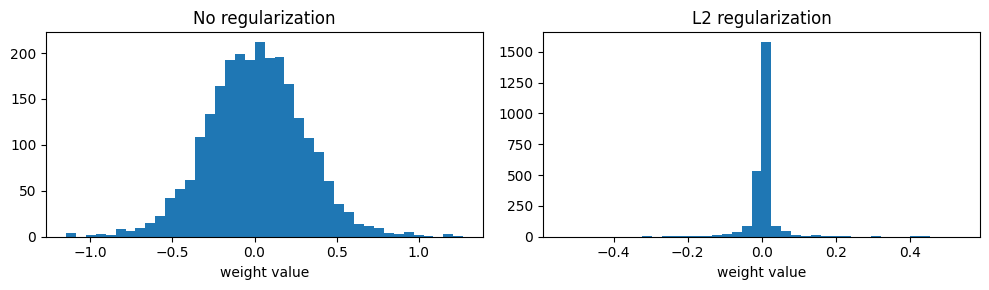

In [25]:
def weight_stats(parameters):
    L = len(parameters) // 2
    all_weights = np.concatenate([parameters[f"W{l}"].flatten() for l in range(1, L+1)])
    return np.mean(np.abs(all_weights)), np.max(np.abs(all_weights))

mean_noreg, max_noreg = weight_stats(params_noreg)
mean_l2, max_l2 = weight_stats(params_l2)

print(f"No regularization: mean |W| = {mean_noreg:.4f}, max |W| = {max_noreg:.4f}")
print(f"L2 regularization : mean |W| = {mean_l2:.4f}, max |W| = {max_l2:.4f}")
print("(L2-regularized weights are noticeably smaller on average -- 'weight decay' in action)")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (name, p) in zip(axes, [("No regularization", params_noreg), ("L2 regularization", params_l2)]):
    all_w = np.concatenate([p[f"W{l}"].flatten() for l in range(1, len(p)//2 + 1)])
    ax.hist(all_w, bins=40)
    ax.set_title(name)
    ax.set_xlabel("weight value")
plt.tight_layout()
plt.show()

## 10. Dropout Regularization

Dropout takes a completely different approach: during training, **randomly "turn off" (zero out) a fraction of units** in a layer on every iteration, then scale the remaining ones up to compensate ("inverted dropout" — the standard implementation). Each training step effectively trains a slightly different, thinned-out sub-network. At **test time**, dropout is switched off entirely and the full network is used.

$$A^{[l]}_{\text{dropout}} = \frac{A^{[l]} * D^{[l]}}{\text{keep\_prob}}, \qquad D^{[l]} = \text{random binary mask, } P(D^{[l]}_{ij}=1) = \text{keep\_prob}$$

The division by `keep_prob` keeps the *expected value* of the activations unchanged, so no rescaling is needed at test time.

In [26]:
def L_model_forward_dropout(X, parameters, keep_prob, seed=None):
    """Same as L_model_forward, but applies inverted dropout to every HIDDEN layer's activations."""
    rng = np.random.RandomState(seed)
    caches = []
    A = X
    L = len(parameters) // 2
    for l in range(1, L):
        A_prev = A
        Z = np.dot(parameters[f"W{l}"], A_prev) + parameters[f"b{l}"]
        A = relu(Z)
        D = (rng.rand(*A.shape) < keep_prob).astype(float)   # dropout mask for this layer
        A = (A * D) / keep_prob                               # inverted dropout: scale to keep E[A] unchanged
        caches.append((A_prev, parameters[f"W{l}"], parameters[f"b{l}"], Z, D))
    ZL = np.dot(parameters[f"W{L}"], A) + parameters[f"b{L}"]
    AL = sigmoid(ZL)
    caches.append((A, parameters[f"W{L}"], parameters[f"b{L}"], ZL, None))  # no dropout on output layer
    return AL, caches

def L_model_backward_dropout(AL, Y, caches, keep_prob):
    grads = {}
    L = len(caches)
    Y = Y.reshape(AL.shape)
    dAL = -(np.divide(Y, np.clip(AL, 1e-8, 1)) - np.divide(1 - Y, np.clip(1 - AL, 1e-8, 1)))

    A_prev, W, b, Z, D = caches[L - 1]
    m = A_prev.shape[1]
    dZ = dAL * sigmoid_derivative(AL)
    grads[f"dW{L}"] = (1.0/m) * np.dot(dZ, A_prev.T)
    grads[f"db{L}"] = (1.0/m) * np.sum(dZ, axis=1, keepdims=True)
    dA = np.dot(W.T, dZ)   # dJ/dA_{L-1}, w.r.t. the POST-dropout value that was fed into the output layer

    for l in reversed(range(1, L)):
        A_prev, W, b, Z, D = caches[l - 1]
        dA = (dA * D) / keep_prob             # undo THIS layer's own dropout scaling first
        dZ = dA * relu_derivative(Z)
        m = A_prev.shape[1]
        grads[f"dW{l}"] = (1.0/m) * np.dot(dZ, A_prev.T)
        grads[f"db{l}"] = (1.0/m) * np.sum(dZ, axis=1, keepdims=True)
        dA = np.dot(W.T, dZ)                  # dJ/dA_{l-1}, ready for the next iteration down

    return grads

def train_deep_dropout(X, Y, layer_dims, keep_prob, num_iterations=3000, alpha=0.3, seed=1):
    parameters = initialize_parameters_deep(layer_dims, seed=seed)
    costs = []
    for it in range(num_iterations):
        AL, caches = L_model_forward_dropout(X, parameters, keep_prob, seed=1000 + it)
        cost = compute_cost(AL, Y)   # cost is computed the usual way; dropout only affects forward/backward
        grads = L_model_backward_dropout(AL, Y, caches, keep_prob)
        parameters = update_parameters_deep(parameters, grads, alpha)
        costs.append(cost)
    return parameters, costs

params_dropout, costs_dropout = train_deep_dropout(X_small, Y_small, big_dims, keep_prob=0.7,
                                                     num_iterations=3000, alpha=0.3)

# Evaluate WITHOUT dropout (standard L_model_forward = dropout off, as it should be at test time)
tr_drop = np.mean(predict_deep(params_dropout, X_small) == Y_small) * 100
dv_drop = np.mean(predict_deep(params_dropout, X_dev) == Y_dev) * 100
print(f"Dropout (keep_prob=0.7): train acc = {tr_drop:.1f}%, dev acc = {dv_drop:.1f}%")
print(f"(compare: no regularization was train=100.0%, dev={np.mean(predict_deep(params_noreg, X_dev)==Y_dev)*100:.1f}%)")

Dropout (keep_prob=0.7): train acc = 100.0%, dev acc = 82.6%
(compare: no regularization was train=100.0%, dev=80.7%)


In [27]:
# Sanity-check the dropout backward pass with a FIXED mask (gradient checking needs a deterministic
# forward function -- with a fixed seed, the same mask is redrawn on every perturbation below).
def gradient_check_dropout(parameters, X, Y, keep_prob, seed=99, epsilon=1e-6, num_checks=6):
    def cost_with_fixed_mask(params):
        AL, _ = L_model_forward_dropout(X, params, keep_prob, seed=seed)
        return compute_cost(AL, Y)

    AL0, caches0 = L_model_forward_dropout(X, parameters, keep_prob, seed=seed)
    grads = L_model_backward_dropout(AL0, Y, caches0, keep_prob)

    rng = np.random.RandomState(0)
    max_diff = 0.0
    for _ in range(num_checks):
        layer = rng.randint(1, len(parameters)//2 + 1)
        name = f"W{layer}"
        idx = tuple(rng.randint(0, s) for s in parameters[name].shape)

        orig = parameters[name][idx]
        parameters[name][idx] = orig + epsilon
        cost_plus = cost_with_fixed_mask(parameters)
        parameters[name][idx] = orig - epsilon
        cost_minus = cost_with_fixed_mask(parameters)
        parameters[name][idx] = orig

        numeric = (cost_plus - cost_minus) / (2 * epsilon)
        analytic = grads[f"d{name}"][idx]
        diff = abs(numeric - analytic)
        max_diff = max(max_diff, diff)
        print(f"{name}{idx}: analytic={analytic:.6f}  numeric={numeric:.6f}  diff={diff:.2e}")

    print(f"\nMax diff: {max_diff:.2e} (should be tiny -- confirms the dropout backward pass is correct)")

params_gc = initialize_parameters_deep([n_x, 6, 5, 1], seed=3)
gradient_check_dropout(params_gc, X_small[:, :20], Y_small[:, :20], keep_prob=0.7)

W1(5, 0): analytic=0.011669  numeric=0.011669  diff=2.12e-11
W2(3, 5): analytic=0.005178  numeric=0.005178  diff=3.18e-11
W3(0, 4): analytic=0.240542  numeric=0.240542  diff=4.35e-11
W3(0, 0): analytic=0.016641  numeric=0.016641  diff=3.47e-12
W1(4, 10): analytic=-0.013721  numeric=-0.013721  diff=2.87e-11
W2(0, 1): analytic=0.028077  numeric=0.028077  diff=2.14e-11

Max diff: 4.35e-11 (should be tiny -- confirms the dropout backward pass is correct)


## 11. Understanding Dropout

Why does randomly deleting units help? Intuition: a unit **can't rely on any one specific input feature or neighboring unit always being present**, since any of them might be dropped on a given iteration. This forces weight to spread out across many connections rather than concentrating heavily on a few — similar in spirit to L2 regularization's weight-shrinking effect, achieved through a different mechanism.

Another common framing: training with dropout is like training a large **ensemble** of thinned sub-networks (a different random subset of units each iteration) and implicitly averaging over them — ensembles are well known to generalize better than any single model.

Below: directly observe two things dropout does — (1) each iteration really does use a different random subset of hidden units, and (2) resulting weights end up smaller/more spread out, echoing the L2 regularization comparison from section 9.

In [28]:
# (1) Show that different iterations really do drop different units
np.random.seed(1)
A_sample = relu(np.random.randn(6, 4))   # pretend hidden-layer activations, 6 units x 4 examples
for it in [0, 1, 2]:
    rng = np.random.RandomState(1000 + it)
    D = (rng.rand(*A_sample.shape) < 0.6).astype(int)
    print(f"iteration {it}: dropout mask (1=kept, 0=dropped):\n{D}\n")

iteration 0: dropout mask (1=kept, 0=dropped):
[[0 1 0 1]
 [0 1 1 1]
 [1 0 1 0]
 [1 1 0 1]
 [0 0 0 1]
 [1 0 1 0]]

iteration 1: dropout mask (1=kept, 0=dropped):
[[1 1 1 1]
 [1 1 1 1]
 [0 1 0 1]
 [1 0 1 1]
 [1 1 0 1]
 [0 0 1 0]]

iteration 2: dropout mask (1=kept, 0=dropped):
[[1 1 1 0]
 [1 1 1 0]
 [0 1 1 0]
 [1 0 1 1]
 [1 1 1 1]
 [0 1 1 1]]



No regularization : mean |W| = 0.2321, max |W| = 1.2711
L2 regularization  : mean |W| = 0.0172, max |W| = 0.5368
Dropout regularization: mean |W| = 0.2385, max |W| = 1.2667


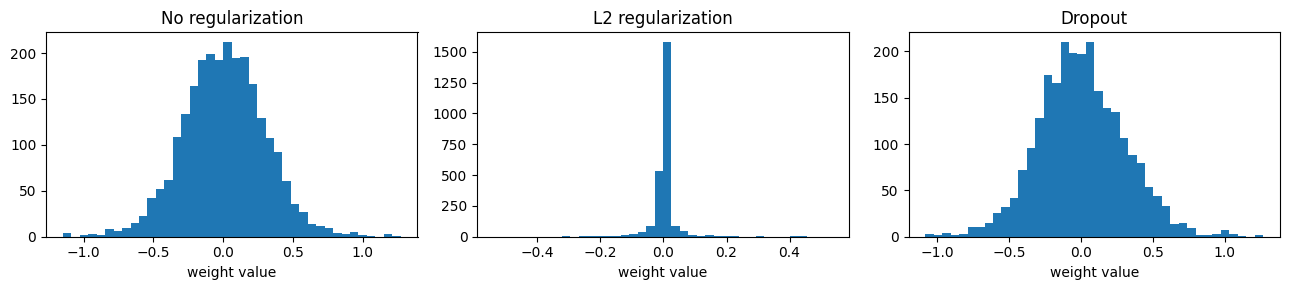

In [29]:
# (2) Compare weight magnitude: no regularization vs L2 vs dropout
mean_drop, max_drop = weight_stats(params_dropout)
print(f"No regularization : mean |W| = {mean_noreg:.4f}, max |W| = {max_noreg:.4f}")
print(f"L2 regularization  : mean |W| = {mean_l2:.4f}, max |W| = {max_l2:.4f}")
print(f"Dropout regularization: mean |W| = {mean_drop:.4f}, max |W| = {max_drop:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, (name, p) in zip(axes, [("No regularization", params_noreg),
                                  ("L2 regularization", params_l2),
                                  ("Dropout", params_dropout)]):
    all_w = np.concatenate([p[f"W{l}"].flatten() for l in range(1, len(p)//2 + 1)])
    ax.hist(all_w, bins=40)
    ax.set_title(name)
    ax.set_xlabel("weight value")
plt.tight_layout()
plt.show()

**A caveat worth knowing:** because dropout makes the cost fluctuate a lot iteration-to-iteration (different random units each time), the usual "check the cost curve is monotonically decreasing" debugging trick doesn't work well with dropout turned on — a common piece of practical advice is to first verify the network trains correctly *without* dropout, then turn dropout on.

## 12. Other Regularization Methods

Two more common techniques, complementary to L2 and dropout:

**Data augmentation.** When collecting more real data is expensive or impossible, create plausible synthetic variations of existing examples (for images: flips, rotations, crops, brightness changes; for tabular data: small random jitter on numeric features). This is a cheaper way to get some of the benefit of "more data," which section 7's basic recipe lists as the main fix for high variance.

**Early stopping.** Track the dev-set cost throughout training. Because training long enough will eventually start overfitting, dev cost typically decreases with training cost initially, but then starts to rise again — stop training near the point where dev cost is at its minimum, instead of running for a fixed, possibly-too-large number of iterations.

Best (early-stopping) iteration: 14, dev cost = 0.3701
Final iteration (3000):          dev cost = 1.6361  (worse -- overfit past the best point)


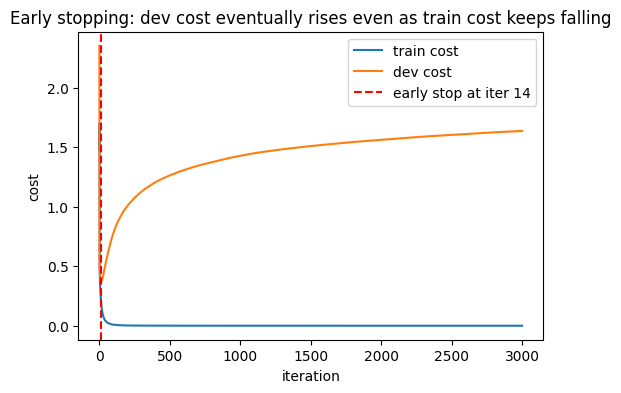

In [30]:
# Early stopping demo: track both train and dev cost every iteration, find the best stopping point
def train_with_dev_tracking(X_tr, Y_tr, X_dv, Y_dv, layer_dims, num_iterations=3000, alpha=0.3, seed=1):
    parameters = initialize_parameters_deep(layer_dims, seed=seed)
    train_costs, dev_costs = [], []
    for it in range(num_iterations):
        AL, caches = L_model_forward(X_tr, parameters)
        train_cost = compute_cost(AL, Y_tr)
        grads = L_model_backward(AL, Y_tr, caches)
        parameters = update_parameters_deep(parameters, grads, alpha)

        AL_dev, _ = L_model_forward(X_dv, parameters)
        dev_cost = compute_cost(AL_dev, Y_dv)

        train_costs.append(train_cost)
        dev_costs.append(dev_cost)
    return parameters, train_costs, dev_costs

_, train_costs_es, dev_costs_es = train_with_dev_tracking(X_small, Y_small, X_dev, Y_dev, big_dims,
                                                             num_iterations=3000, alpha=0.3)

best_iteration = int(np.argmin(dev_costs_es))
print(f"Best (early-stopping) iteration: {best_iteration}, dev cost = {dev_costs_es[best_iteration]:.4f}")
print(f"Final iteration (3000):          dev cost = {dev_costs_es[-1]:.4f}  (worse -- overfit past the best point)")

plt.figure(figsize=(6, 4))
plt.plot(train_costs_es, label="train cost")
plt.plot(dev_costs_es, label="dev cost")
plt.axvline(best_iteration, color="red", linestyle="--", label=f"early stop at iter {best_iteration}")
plt.xlabel("iteration"); plt.ylabel("cost")
plt.title("Early stopping: dev cost eventually rises even as train cost keeps falling")
plt.legend()
plt.show()